# Torch implementation of the minimax game
Below are the required libraries to run this adversarial training problem

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch

# Fized seeds
dtype = torch.float32
np.random.seed(42)
torch.manual_seed(42)

# Parameters of the experiment
SIGMA = torch.tensor([[1.0, -0.5], [-0.5, 1.0]], dtype=dtype)
C = torch.tensor([[1.0, 0.7], [0.7, 1.0]], dtype=dtype)

## Agent parametrization
The Agent is parametrized by an ML with 2 hidden layers of 64 neurons each.

In [96]:
class Agent(nn.Module):
    def __init__(self, d = 2, hidden_dim = 64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d, hidden_dim), nn.Tanh(),
                                nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
                                nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
                                nn.Linear(hidden_dim, 1))

    def forward(self, x):
        return self.net(x)


def compute_theta(agent, x):
    x = x.clone().detach().requires_grad_(True)
    phi = agent(x)

    # sum over batch so autograd gives gradient for every sample
    theta = torch.autograd.grad(outputs = phi.sum(), inputs =x,
                                 create_graph=True)[0]
    
    return theta, x


## Nature parametrization
Since we are working in dimension $d=2$, the skew-symmetric matrix has one parameter only which is the scalar $\beta$.

In [97]:
class NatureDrift(nn.Module):
    def __init__(self, C, SIGMA, beta_bound = 10.0):
        super().__init__()
        self.register_buffer("c", C)
        self.register_buffer("Sigma", SIGMA)
        self.register_buffer('sigma_inv', torch.linalg.inv(SIGMA))

        self.raw_beta = nn.Parameter(torch.zeros(1))
        self.beta_bound = beta_bound

    def beta(self):
        return self.beta_bound * torch.tanh(self.raw_beta)
    
    def skew_matrix(self):
        beta = self.beta()
        S = torch.zeros_like(self.c)
        S[0, 1] = beta
        S[1, 0] = -beta
        return S
    
    def B(self):
        S = self.skew_matrix()
        B = (0.5*self.c + S) @ self.sigma_inv
        return B

## Monte-Carlo samples for the loss

As discussed in the paper, we chose to sample from the invariant distribution rather than sampling entire trajectories from the dynamics and computing discretized stochastic integrals along these full trajectories.

In [98]:
# This function sampels a tensor from the invariant distribution N(0, Sigma)
def sample_invariant(batch_size, SIGMA, device="cpu", dtype=torch.float32):

    Sigma_np = SIGMA.detach().cpu().numpy()
    d = Sigma_np.shape[0]

    x_np = np.random.multivariate_normal(
        mean=np.zeros(d),
        cov=Sigma_np,
        size=batch_size
    )

    return torch.tensor(x_np, device=device, dtype=dtype)


def growth_rate_estimate(agent, nature, batch_size=4096):
    """
    g(alpha, beta) = E[-theta(x)^T B x - 1/2 theta(x)^T c theta(x)] where theta(x) = grad phi_alpha(x)

    """

    SIGMA = nature.Sigma
    C = nature.c
    B = nature.B()

    # Sample x ~ N(0, Sigma)
    x = sample_invariant(
        batch_size,
        SIGMA,
        device=SIGMA.device,
        dtype=SIGMA.dtype
    )

    # Compute theta(x) = grad_x phi(x)
    theta, x = compute_theta(agent, x)

    # Bx, shape (batch_size, d)
    Bx = x @ B.T

    # theta^T Bx, shape (batch_size,)
    drift_term = torch.sum(theta * Bx, dim=1)

    # C theta, shape (batch_size, d)
    Ctheta = theta @ C.T

    # theta^T C theta, shape (batch_size,)
    risk_term = torch.sum(theta * Ctheta, dim=1)

    # integrand for each sample
    integrand = -drift_term - 0.5 * risk_term

    # Monte Carlo average
    return integrand.mean()




## Training loop
In the cell below, we build the entire training loop (instantation of Nature and Agent networks). The batch size simply corresponds to the number of samples drawn from $\mathcal{N}_\infty$

In [99]:
nature = NatureDrift(C, SIGMA, beta_bound=10.0)
agent = Agent(d=2, hidden_dim=64)

agent_optimizer = torch.optim.Adam(agent.parameters(), lr=1e-3)
nature_optimizer = torch.optim.Adam(nature.parameters(), lr=5e-4)

num_epochs = 5000
batch_size = 8192

history = {
    "g": [],
    "beta": []
}

mod_epoch_print = 150

for epoch in range(num_epochs):

    # NATURE STEP (Agent is frozen)
    for p in agent.parameters():
        p.requires_grad_(False)
    for p in nature.parameters():
        p.requires_grad_(True)

    nature_optimizer.zero_grad()

    g_hat = growth_rate_estimate(agent, nature, batch_size=batch_size)
    nature_loss = g_hat

    nature_loss.backward()
    nature_optimizer.step()

    # AGENT STEP (Nature is frozen)
    for p in agent.parameters():
        p.requires_grad_(True)
    for p in nature.parameters():
        p.requires_grad_(False)

    agent_optimizer.zero_grad()

    g_hat = growth_rate_estimate(agent, nature, batch_size=batch_size)
    agent_loss = -g_hat

    agent_loss.backward()
    agent_optimizer.step()

    # PRINTING
    if epoch % mod_epoch_print == 0:
        with torch.no_grad():
            beta_val = nature.beta().item()
            g_val = g_hat.item()

        history["g"].append(g_val)
        history["beta"].append(beta_val)

        print(f"Epoch {epoch:5d} | g_hat = {g_val:.6f} | beta = {beta_val:.4f}")

Epoch     0 | g_hat = -0.039651 | beta = -0.0050
Epoch   150 | g_hat = 0.446222 | beta = -0.0227
Epoch   300 | g_hat = 0.444929 | beta = 0.0390
Epoch   450 | g_hat = 0.445646 | beta = 0.0564
Epoch   600 | g_hat = 0.452367 | beta = 0.0676
Epoch   750 | g_hat = 0.451120 | beta = 0.0976
Epoch   900 | g_hat = 0.461784 | beta = 0.1035
Epoch  1050 | g_hat = 0.457816 | beta = 0.0936
Epoch  1200 | g_hat = 0.436119 | beta = 0.1079
Epoch  1350 | g_hat = 0.447053 | beta = 0.1057
Epoch  1500 | g_hat = 0.449597 | beta = 0.0854
Epoch  1650 | g_hat = 0.458345 | beta = 0.0847
Epoch  1800 | g_hat = 0.446814 | beta = 0.0703
Epoch  1950 | g_hat = 0.448152 | beta = 0.0275
Epoch  2100 | g_hat = 0.452662 | beta = 0.0118
Epoch  2250 | g_hat = 0.440261 | beta = 0.0112
Epoch  2400 | g_hat = 0.451073 | beta = 0.0250
Epoch  2550 | g_hat = 0.441078 | beta = 0.0100
Epoch  2700 | g_hat = 0.442672 | beta = -0.0034
Epoch  2850 | g_hat = 0.457541 | beta = 0.0006
Epoch  3000 | g_hat = 0.445106 | beta = -0.0239
Epoch  3

## Comparison with analytical results
In the cell below, we compare the results of the Agent network versus the closed-form solutions we computed in Part 1

Analytical robust-optimal growth rate: 0.450000
Learned final growth rate estimate:    0.448799
Absolute error:                       0.001201
Learned beta:                         0.005601


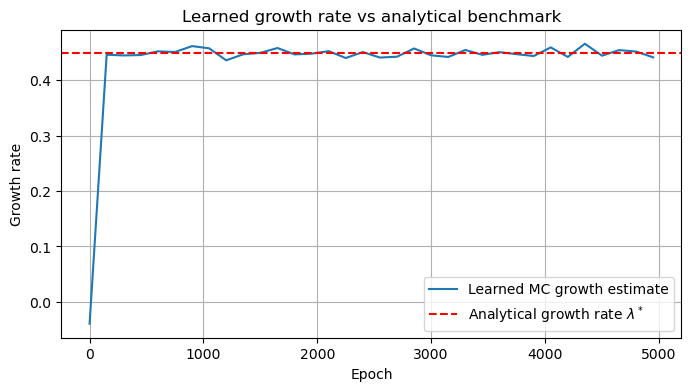

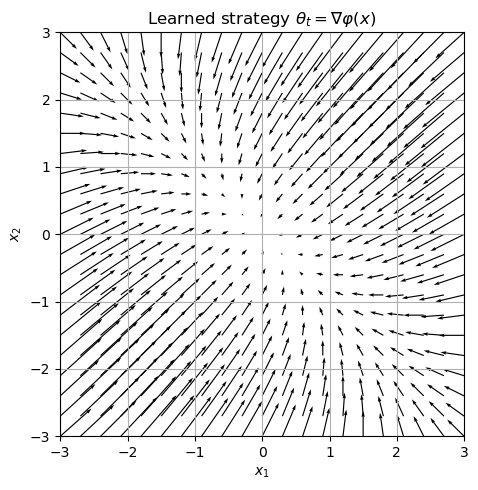

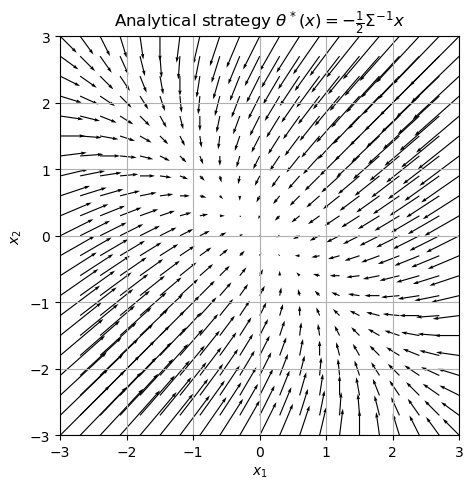

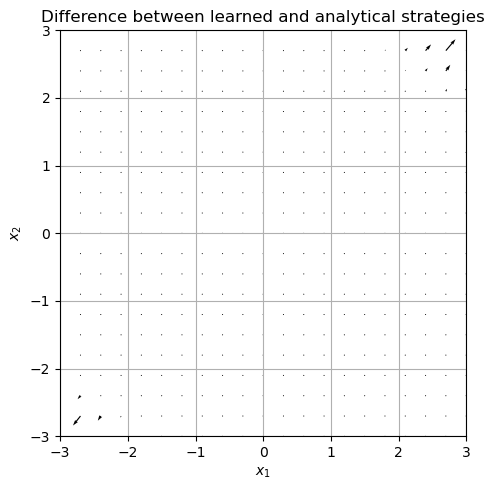

In [100]:
Sigma = nature.Sigma
C = nature.c
Sigma_inv = torch.linalg.inv(Sigma)

lambda_star = 0.125 * torch.trace(C @ Sigma_inv).item()

# Estimate final learned growth rate with a larger MC batch
g_final = growth_rate_estimate(agent, nature, batch_size=20000).item()

print(f"Analytical robust-optimal growth rate: {lambda_star:.6f}")
print(f"Learned final growth rate estimate:    {g_final:.6f}")
print(f"Absolute error:                       {abs(g_final - lambda_star):.6f}")
print(f"Learned beta:                         {nature.beta().item():.6f}")

# GRAPHS OF THE LEARNED GROWTH RATE OVER TRAINING

g_history = np.array(history["g"])

logging_every = mod_epoch_print
epochs_logged = logging_every * np.arange(len(g_history))

plt.figure(figsize=(8, 4))
plt.plot(epochs_logged, g_history, label="Learned MC growth estimate")
plt.axhline(lambda_star, linestyle="--", color = 'red', label=r"Analytical growth rate $\lambda^*$")
plt.xlabel("Epoch")
plt.ylabel("Growth rate")
plt.title("Learned growth rate vs analytical benchmark")
plt.legend()
plt.grid(True)
plt.savefig('plots/growth_rate_training.png', dpi=300)
plt.show()

# HELPER: compute learned theta on a grid for plotting
def compute_theta_eval(agent, x):
    x = x.clone().detach().requires_grad_(True)
    phi = agent(x).sum()

    theta = torch.autograd.grad(
        outputs=phi,
        inputs=x,
        create_graph=False
    )[0]

    return theta.detach()

# AGENT STRATEGY VECTOR FIELD PLOTS
grid_min, grid_max = -3.0, 3.0
num_grid = 21

x1 = np.linspace(grid_min, grid_max, num_grid)
x2 = np.linspace(grid_min, grid_max, num_grid)

X1, X2 = np.meshgrid(x1, x2)

grid_np = np.column_stack([X1.ravel(), X2.ravel()])
grid = torch.tensor(grid_np, dtype=Sigma.dtype, device=Sigma.device)

# Learned strategy
theta_learned = compute_theta_eval(agent, grid).cpu().numpy()

# Analytical strategy: theta*(x) = -1/2 Sigma^{-1} x
theta_star = (-0.5 * (grid @ Sigma_inv.T)).detach().cpu().numpy()

U_learned = theta_learned[:, 0].reshape(num_grid, num_grid)
V_learned = theta_learned[:, 1].reshape(num_grid, num_grid)

U_star = theta_star[:, 0].reshape(num_grid, num_grid)
V_star = theta_star[:, 1].reshape(num_grid, num_grid)


plt.figure(figsize=(6.5, 5))
plt.quiver(X1, X2, U_learned, V_learned, angles="xy", scale_units="xy", scale=4)
plt.title("Learned strategy $\\theta_{t}=\\nabla\\varphi(x)$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xlim(grid_min, grid_max)
plt.ylim(grid_min, grid_max)
plt.gca().set_aspect("equal")
plt.grid(True)
plt.tight_layout()
plt.savefig('plots/agent_strategy_VF.png', dpi=300)
plt.show()

plt.figure(figsize=(6.5, 5))
plt.quiver(X1, X2, U_star, V_star, angles="xy", scale_units="xy", scale=4)
plt.title(r"Analytical strategy $\theta^*(x)=-\frac{1}{2}\Sigma^{-1}x$")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xlim(grid_min, grid_max)
plt.ylim(grid_min, grid_max)
plt.gca().set_aspect("equal")
plt.grid(True)
plt.tight_layout()
plt.savefig('plots/true_strategy_VF.png', dpi=300)
plt.show()

# VECTOR FIELD DIFFERENCE PLOT  
U_diff = U_learned - U_star
V_diff = V_learned - V_star
plt.figure(figsize=(6.5, 5))
plt.quiver(X1, X2, U_diff, V_diff, angles="xy",
              scale_units="xy", scale=4)
plt.title("Difference between learned and analytical strategies")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xlim(grid_min, grid_max)
plt.ylim(grid_min, grid_max)
plt.gca().set_aspect("equal")
plt.grid(True)
plt.tight_layout()
plt.savefig('plots/strategy_difference_VF.png', dpi=300)
plt.show()

In [102]:
print((g_final - lambda_star)/lambda_star)

-0.002668301158416225
